In [170]:
import pandas as pd

In [172]:
df=pd.read_csv('boston.csv')
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [174]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [176]:
df.duplicated().sum()

0

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [180]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


# EDA

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

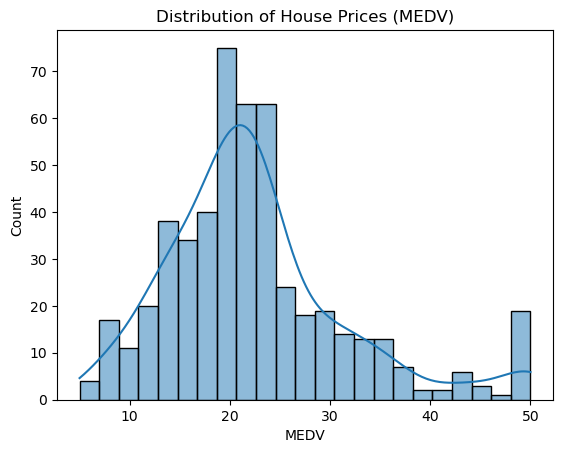

In [185]:
sns.histplot(df['MEDV'],kde=True)        #the parameter kde=True adds a Kernel Density Estimate (KDE) curve to the histogram.
plt.title('Distribution of House Prices (MEDV)')
plt.show()

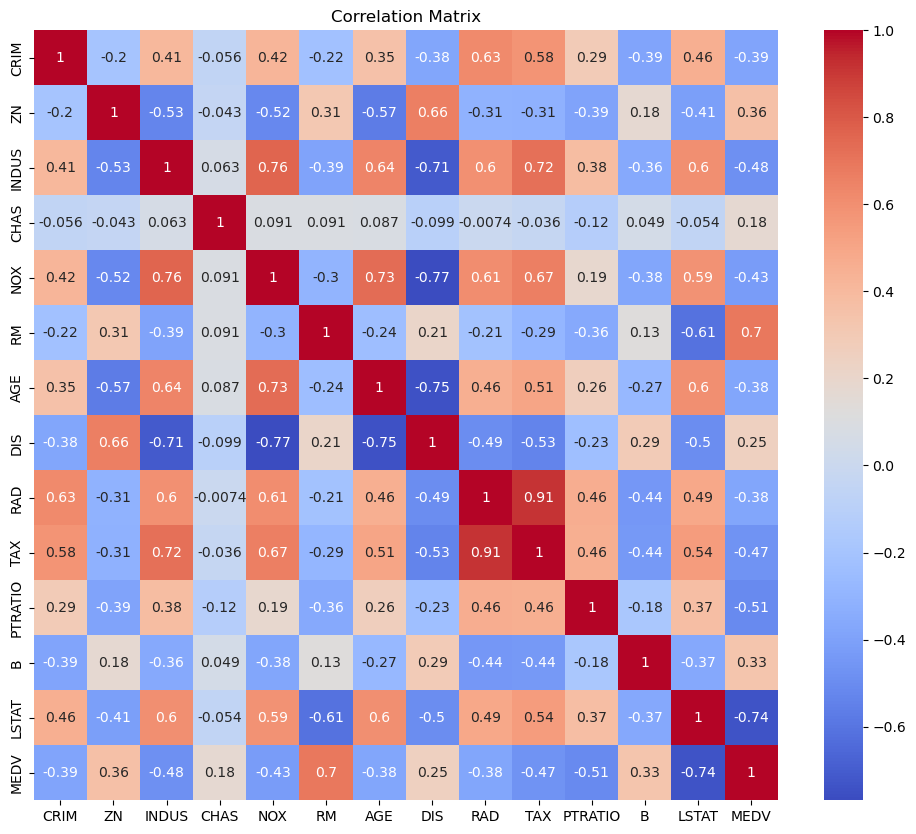

In [186]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

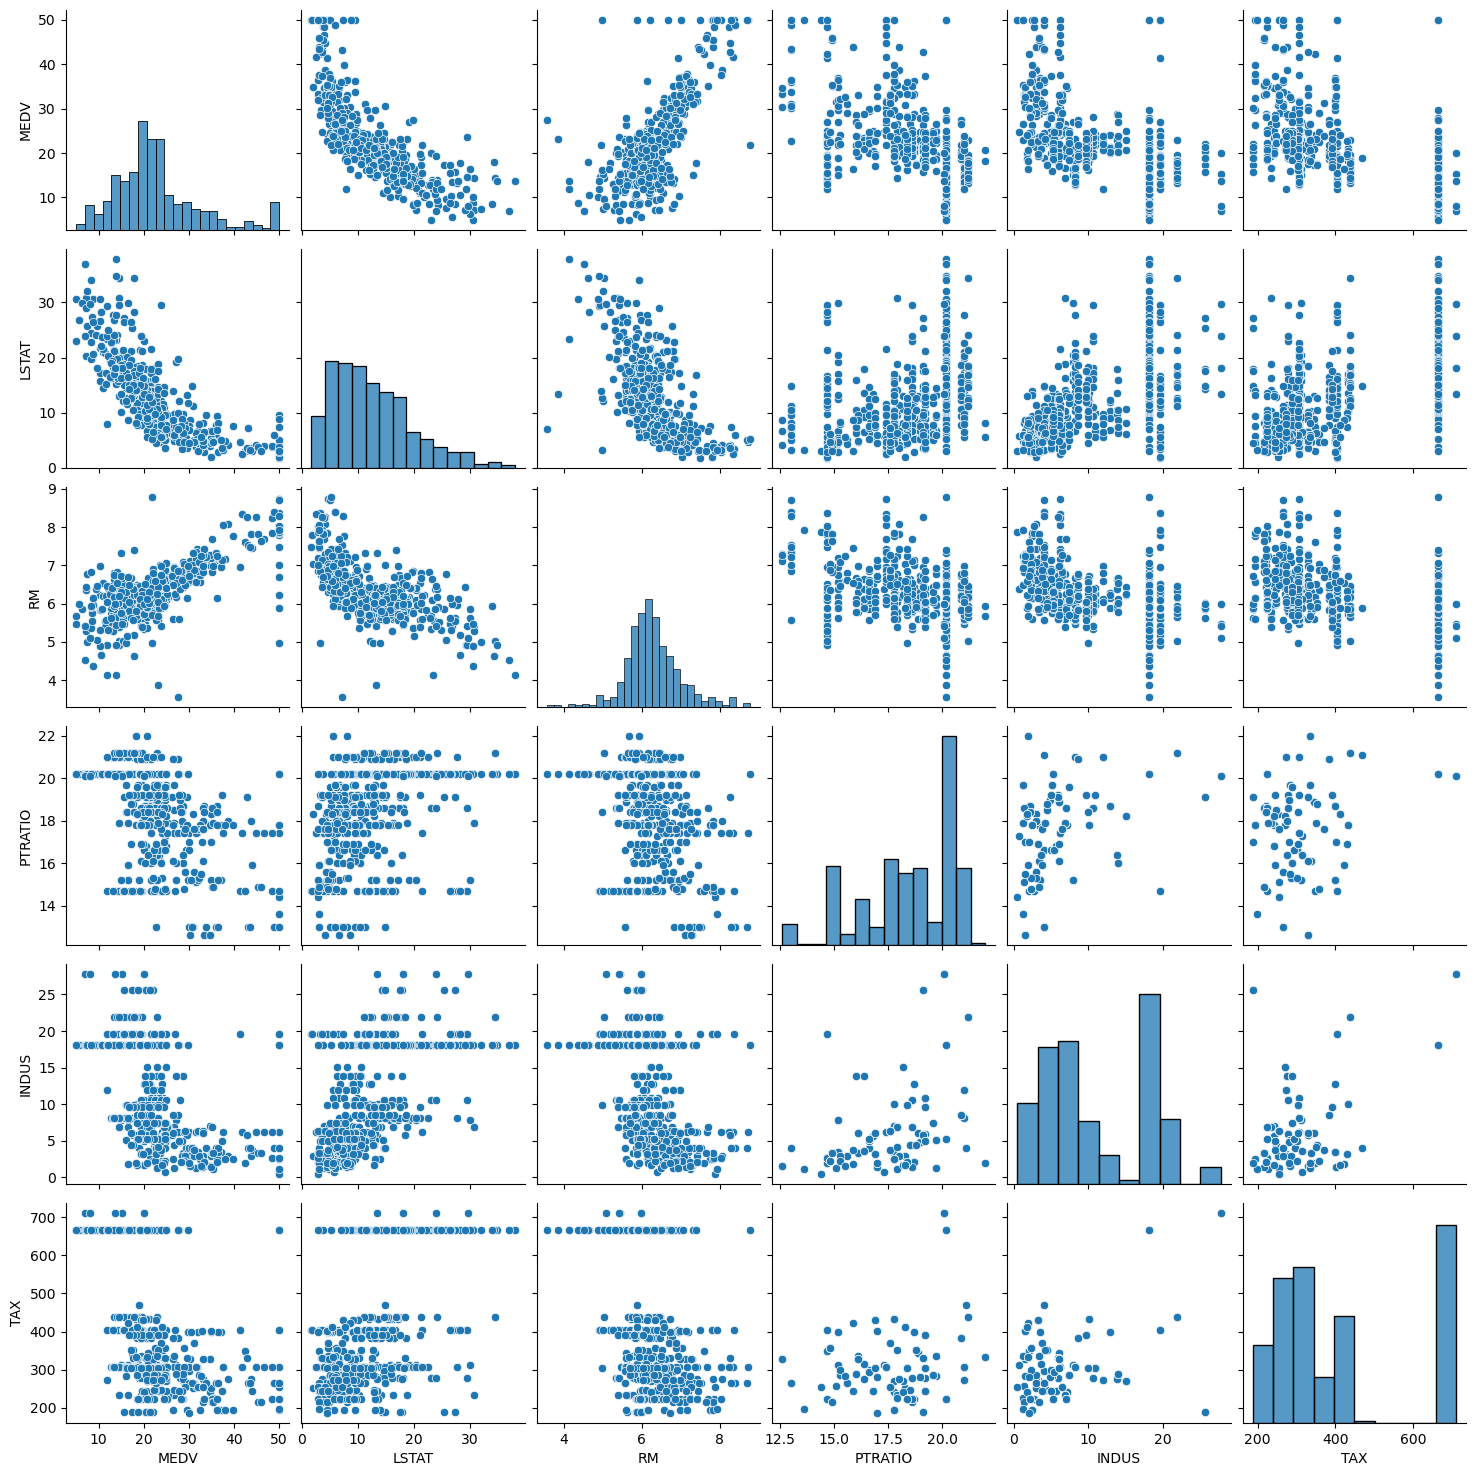

In [188]:
# Choose top correlated features with MEDV
top_features = df.corr()['MEDV'].abs().sort_values(ascending=False).head(6).index
sns.pairplot(df[top_features])
plt.show()

### df.corr()['MEDV']: Extracts just the correlation values of all features with the MEDV column (the target).
### .abs():Takes the absolute value, so we treat both strong positive and negative correlations equally. Example: +0.7 and -0.7 are both considered equally strong.
### .sort_values(ascending=False): Sorts the correlation values in descending order, i.e., from strongest to weakest correlation.
### .head(6): Picks the top 6 features that are most correlated with MEDV.
### .index: Extracts just the names of those top 6 features (not the correlation values themselves).

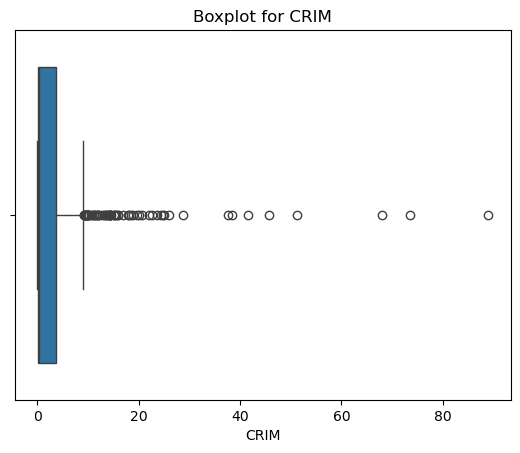

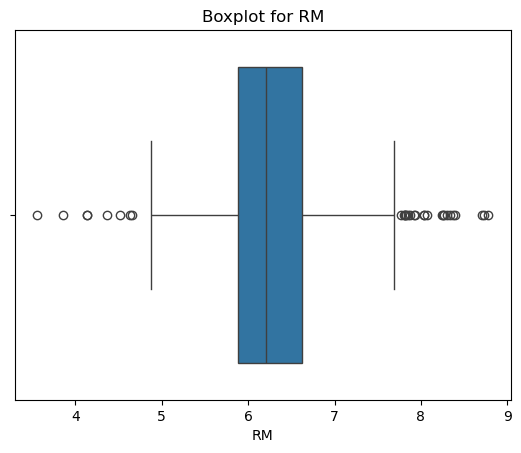

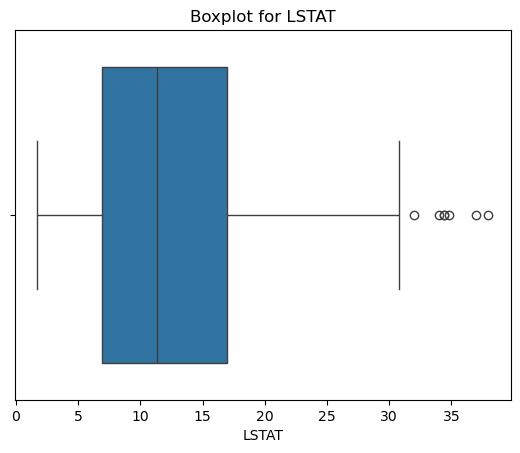

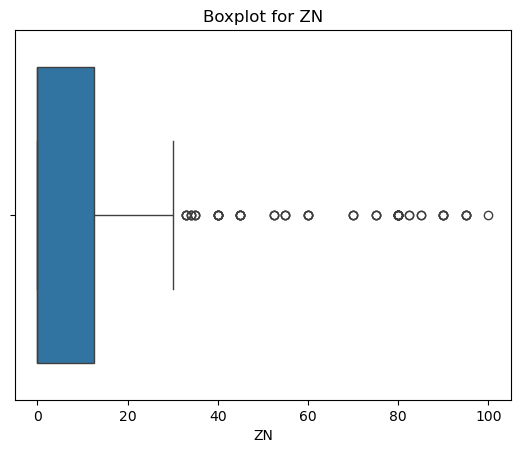

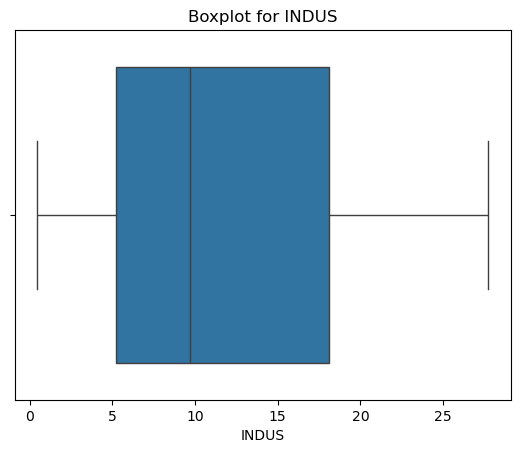

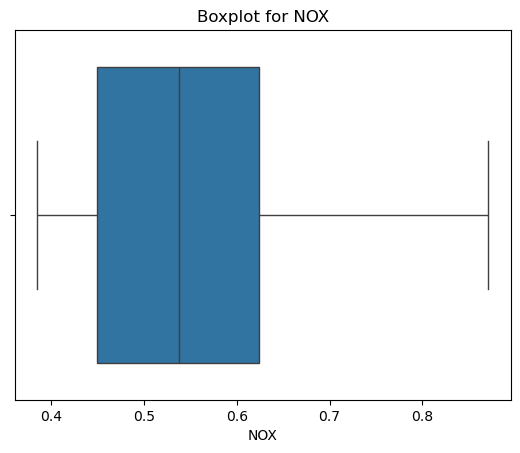

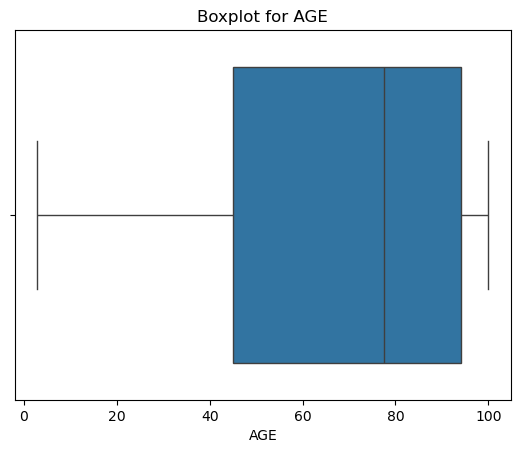

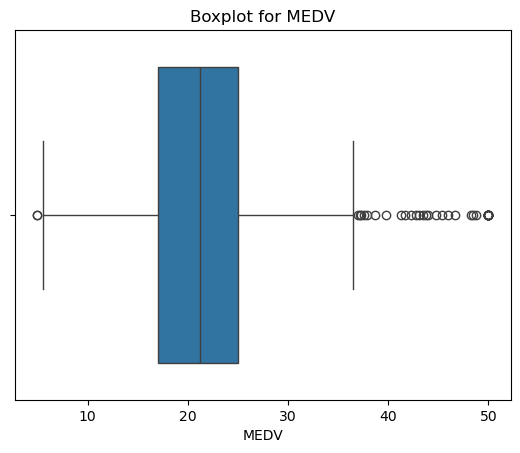

In [191]:
features=['CRIM','RM', 'LSTAT','ZN','INDUS','NOX','AGE','MEDV']
for feature in features:
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot for {feature}')
    plt.show()

### Not handling these outliers since these outliers are real values and meaningful (e.g., some towns genuinely have high crime or big houses), so I will use models which are robust and less sensitive to outliers

# Train Test Split

In [194]:
X=df.drop('MEDV',axis=1)
y=df['MEDV']

In [195]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Data Preprocessing

In [197]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# Linear Regression

In [199]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [200]:
y_predict=lr.predict(X_test)

# Model Evaluation of Linear Regression

In [202]:
from sklearn.metrics import mean_squared_error,r2_score

In [205]:
print("Mean Squared Error: ",mean_squared_error(y_test,y_predict))
print("r2 Score: ",r2_score(y_test,y_predict))

Mean Squared Error:  24.291119474973513
r2 Score:  0.668759493535632


# Random Forest

In [204]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

In [206]:
rf_predict=rf.predict(X_test)

# Model Evaluation of Random Forest

In [208]:
print("Mean Squared Error: ",mean_squared_error(y_test,rf_predict))
print("r2 Score: ",r2_score(y_test,rf_predict))

Mean Squared Error:  7.863646382352944
r2 Score:  0.8927691161771735


# GradientBoostingRegressor

In [210]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor()
gbr.fit(X_train,y_train)

GradientBoostingRegressor()

In [211]:
gbr_predict=gbr.predict(X_test)

# Model Evaluation of GradientBoostingRegressor

In [213]:
print("Mean Squared Error: ",mean_squared_error(y_test,gbr_predict))
print("r2 Score: ",r2_score(y_test,gbr_predict))

Mean Squared Error:  6.17383909655012
r2 Score:  0.9158118014578245


# Hyperparamter Tuning on RandomForestRegressor

In [215]:
param_grid={
    'n_estimators': [100,200,300],
    'max_depth': [3,4,5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [216]:
forest_grid=GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,scoring='r2',n_jobs=-1)

In [217]:
forest_grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5], 'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [218]:
forest_grid_predict=forest_grid.predict(X_test)

In [219]:
print("Best Parameters:", forest_grid.best_params_)
print("Mean Squared Error:", mean_squared_error(y_test,forest_grid_predict))
print("R2 Score:", r2_score(y_test,forest_grid_predict))

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Mean Squared Error: 10.48178178005691
R2 Score: 0.8570674888387859


# HYPERPARAMETER TUNING on GradientBoostingRegressor

In [221]:
from sklearn.model_selection import GridSearchCV

In [222]:
param_grid={
    'n_estimators': [100,200,300],
    'learning_rate': [0.05,0.1,0.2],
    'max_depth': [3,4,5]
}

In [223]:
gridsearch=GridSearchCV(estimator=gbr,param_grid=param_grid,cv=5,scoring='r2',n_jobs=-1)

In [224]:
gridsearch.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [225]:
best_gbr=gridsearch.best_estimator_

In [226]:
new_gbr_predict=best_gbr.predict(X_test)

In [227]:
print("Best Parameters:", gridsearch.best_params_)
print("Mean Squared Error:", mean_squared_error(y_test,new_gbr_predict))
print("R2 Score:", r2_score(y_test,new_gbr_predict))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Mean Squared Error: 6.206918301193175
R2 Score: 0.9153607241614201


# COMPARING MODELS ON R2 SCORE AND MSE

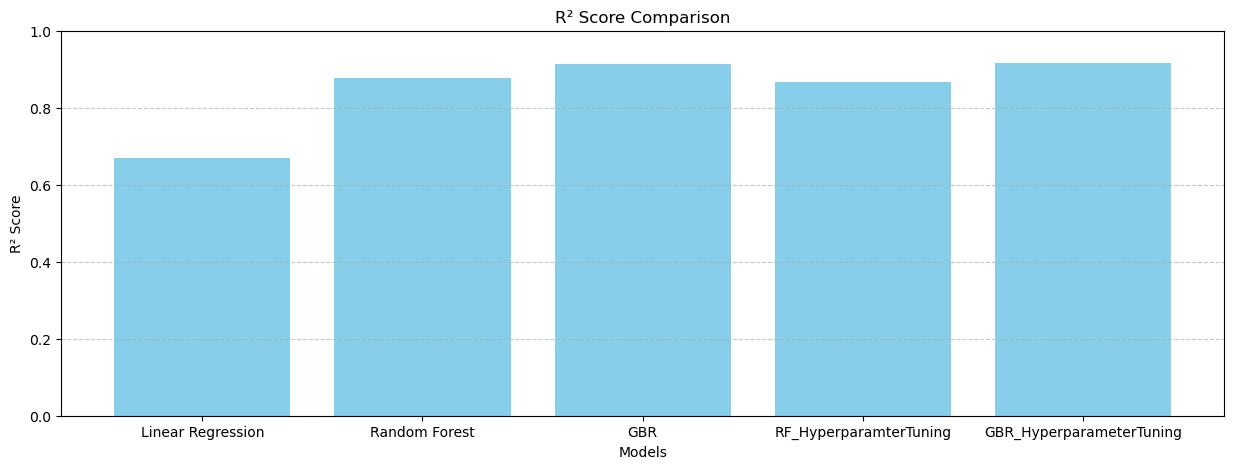

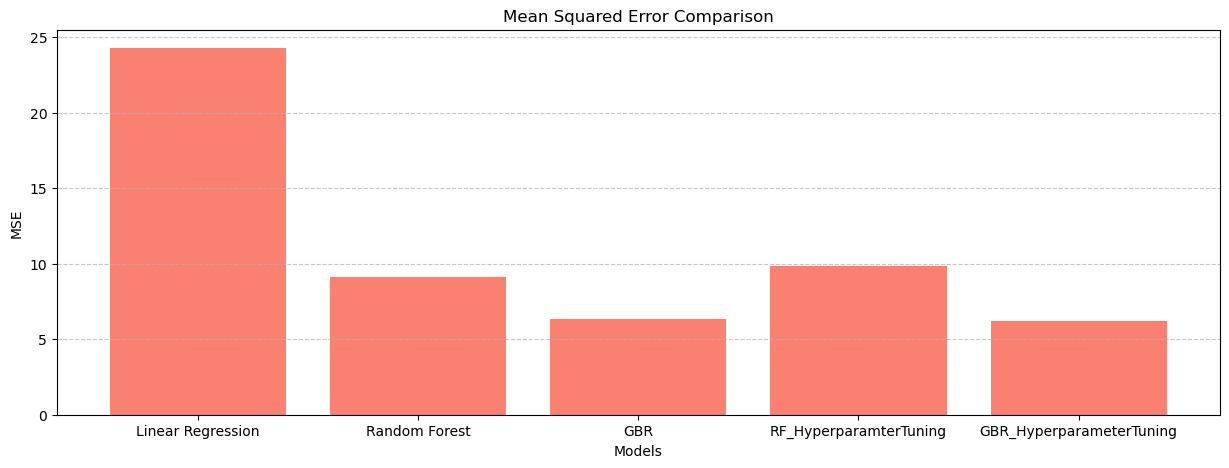

In [229]:
model_names = ['Linear Regression', 'Random Forest', 'GBR','RF_HyperparamterTuning','GBR_HyperparameterTuning']
r2_scores = [0.668759493535632,0.8759934217531538,0.9133945647453107, 0.8655736707808178,0.915675556515839] 
mse_scores = [24.291119474973513,9.093871519607843,6.351104209472777,9.85799127799769,6.183830453582373]     

# Plot R² Scores
plt.figure(figsize=(15,5))
plt.bar(model_names, r2_scores, color='skyblue')
plt.ylim(0, 1)
plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.xlabel("Models")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot MSE Scores
plt.figure(figsize=(15,5))
plt.bar(model_names, mse_scores, color='salmon')
plt.title("Mean Squared Error Comparison")
plt.ylabel("MSE")
plt.xlabel("Models")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### Linear regression has highest MSE that is least well performed (mse should be lower)

# GradientBoostingRegressor with tuning is the best model here for this dataset.

# Feature Importance Plot (Which feature contributed the most)

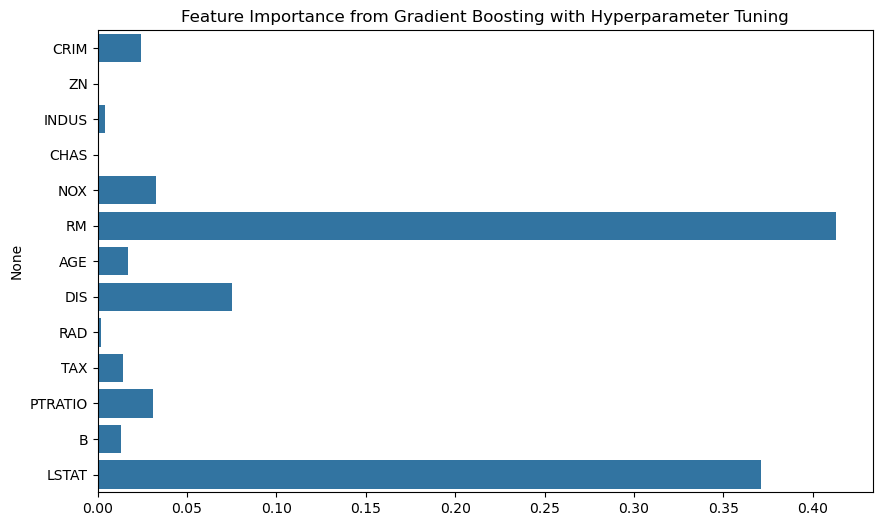

In [233]:
feature_importances = best_gbr.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=features)
plt.title("Feature Importance from Gradient Boosting with Hyperparameter Tuning")
plt.show()

### .feature_importances_ is an attribute of tree-based models that tells how important each feature was in making predictions.
### You get a NumPy array like:
### [0.25, 0.01, 0.14, ...] → where higher values = more important.

### features = X.columns
### X is the original dataset (with features) to know which number corresponds to which feature.
